# ============================================================
# 07 | Evaluation & Comparison — All Models
# ============================================================
# This notebook loads saved training histories and evaluation
# metrics from JSON/CSV files and performs a comprehensive
# comparison across all implemented architectures.
# No GPU or model re-loading required.
# ============================================================

In [1]:

import sys
sys.path.append(".")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────
RESULTS_DIR = Path("../results")
MODELS_DIR  = Path("../models")

# ── Constants ────────────────────────────────────────────────
CLASS_NAMES = ["Glass", "Metal", "Organic", "Paper", "Plastic"]

# ── Plot style ───────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":      130,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titlesize":  13,
    "axes.labelsize":  11,
    "legend.fontsize":  9,
    "font.family":    "DejaVu Sans",
})
sns.set_palette("tab10")

print("✅ Imports done")
print(f"   RESULTS_DIR : {RESULTS_DIR.resolve()}")
print(f"   Exists      : {RESULTS_DIR.exists()}")

✅ Imports done
   RESULTS_DIR : D:\HNU\waste_classifier\results
   Exists      : True


In [2]:
# ============================================================
# Cell 2 | Load All Saved Results
# ============================================================
def load_json(filename):
    path = RESULTS_DIR / filename
    if path.exists():
        with open(path) as f:
            return json.load(f)
    else:
        print(f"  ⚠️  Not found: {filename}")
        return None

# ── Training Histories ───────────────────────────────────────
baseline_history    = load_json("baseline_cnn_history.json")
improved_history    = load_json("improved_cnn_history.json")
resnet_s1_history   = load_json("resnet50_stage1_history.json")
resnet_ft_history   = load_json("resnet50_finetuned_history.json")
effnet_s1_history   = load_json("efficientnet_b3_stage1_history.json")
effnet_ft_history   = load_json("efficientnet_b3_finetuned_history.json")
vit_history         = load_json("vit_history.json")

# ── Evaluation Results ───────────────────────────────────────
vit_results         = load_json("vit_results.json")
ensemble_results    = load_json("ensemble_metrics.json")

# ── Master CSV ───────────────────────────────────────────────
csv_path = RESULTS_DIR / "all_models_metrics.csv"
if csv_path.exists():
    df_csv = pd.read_csv(csv_path)
    print("✅ all_models_metrics.csv loaded")
    print(df_csv.to_string(index=False))
else:
    print("⚠️  all_models_metrics.csv not found")

# ── Summary ──────────────────────────────────────────────────
histories = {
    "Baseline CNN":     baseline_history,
    "Improved CNN":     improved_history,
    "ResNet50 Stage1":  resnet_s1_history,
    "ResNet50 FT":      resnet_ft_history,
    "EffNetB3 Stage1":  effnet_s1_history,
    "EffNetB3 FT":      effnet_ft_history,
    "ViT":              vit_history,
}

print("\n── History files ───────────────────────────────────────")
for name, h in histories.items():
    status = f"{len(h['train_acc'])} epochs" if h and "train_acc" in h else "❌ missing / unexpected keys"
    print(f"  {name:<20} {status}")

✅ all_models_metrics.csv loaded
              model  test_accuracy  macro_f1  macro_precision  macro_recall
       baseline_cnn       0.619400  0.592100         0.623000      0.598600
       improved_cnn       0.704300  0.702300         0.709500      0.700600
       <<<<<<< HEAD            NaN       NaN              NaN           NaN
           resnet50       0.958065  0.956585         0.956822      0.956939
    efficientnet_b3       0.960215  0.959414         0.959234      0.960149
            =======            NaN       NaN              NaN           NaN
       baseline_cnn       0.619400  0.592100         0.623000      0.598600
       improved_cnn       0.704300  0.702300         0.709500      0.700600
>>>>>>> origin/main            NaN       NaN              NaN           NaN

── History files ───────────────────────────────────────
  Baseline CNN         9 epochs
  Improved CNN         25 epochs
  ResNet50 Stage1      5 epochs
  ResNet50 FT          17 epochs
  EffNetB3 Stage1   

In [3]:
print("── vit_results.json keys ──────────────────────────")
print(json.dumps(vit_results, indent=2))

print("\n── ensemble_metrics.json keys ─────────────────────")
print(json.dumps(ensemble_results, indent=2))

── vit_results.json keys ──────────────────────────
{
  "model": "ViT (from scratch)",
  "architecture": {
    "type": "Vision Transformer",
    "img_size": 224,
    "patch_size": 16,
    "embed_dim": 256,
    "depth": 6,
    "num_heads": 8,
    "mlp_dim": 1024,
    "dropout": 0.1,
    "num_classes": 5,
    "total_params": 4987909
  },
  "training": {
    "epochs_ran": 30,
    "best_val_acc": 0.6931,
    "best_val_loss": 0.8203,
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
    "learning_rate": 0.0001,
    "batch_size": 32,
    "patience": 10
  },
  "evaluation": {
    "test_accuracy": 0.7161,
    "per_class_f1": {
      "Glass": 0.72,
      "Metal": 0.6,
      "Organic": 0.84,
      "Paper": 0.73,
      "Plastic": 0.66
    }
  },
  "ensemble": {
    "models": [
      "ViT",
      "ResNet50",
      "EfficientNetB3"
    ],
    "strategy": "soft voting",
    "test_accuracy": 0.972
  },
  "artifacts": {
    "model_checkpoint": "models/vit_best.pth",
    "training_curves"

In [4]:
# ============================================================
# Cell 3 | Clean CSV & Build Master Metrics Table
# ============================================================

# ── Step 1: Drop corrupted rows (git merge conflict artifacts) ──
conflict_markers = ["<<<<<<<", "=======", ">>>>>>>"]
mask = df_csv["model"].apply(lambda x: not any(m in str(x) for m in conflict_markers))
df_clean = df_csv[mask].drop_duplicates(subset="model").reset_index(drop=True)

print("✅ Cleaned CSV rows:")
print(df_clean.to_string(index=False))

# ── Step 2: Add ViT row from JSON ────────────────────────────
vit_per_class_f1 = vit_results["evaluation"]["per_class_f1"]
vit_macro_f1 = round(np.mean(list(vit_per_class_f1.values())), 6)

vit_row = pd.DataFrame([{
    "model":           "vit",
    "test_accuracy":   vit_results["evaluation"]["test_accuracy"],
    "macro_f1":        vit_macro_f1,
    "macro_precision": float("nan"),
    "macro_recall":    float("nan"),
}])

# ── Step 3: Add Ensemble row from JSON ───────────────────────
ensemble_row = pd.DataFrame([{
    "model":           "ensemble",
    "test_accuracy":   ensemble_results["test_accuracy"],
    "macro_f1":        ensemble_results["macro_f1"],
    "macro_precision": ensemble_results["macro_precision"],
    "macro_recall":    ensemble_results["macro_recall"],
}])

# ── Step 4: Combine everything ───────────────────────────────
df_all = pd.concat([df_clean, vit_row, ensemble_row], ignore_index=True)

# ── Step 5: Enforce display order ────────────────────────────
order = ["baseline_cnn", "improved_cnn", "resnet50", "efficientnet_b3", "vit", "ensemble"]
label_map = {
    "baseline_cnn":    "Baseline CNN",
    "improved_cnn":    "Improved CNN",
    "resnet50":        "ResNet50",
    "efficientnet_b3": "EfficientNetB3",
    "vit":             "ViT (scratch)",
    "ensemble":        "Ensemble",
}
df_all["model"] = pd.Categorical(df_all["model"], categories=order, ordered=True)
df_all = df_all.sort_values("model").reset_index(drop=True)
df_all["Model"] = df_all["model"].map(label_map)

# ── Step 6: Convert to percentage ────────────────────────────
for col in ["test_accuracy", "macro_f1", "macro_precision", "macro_recall"]:
    df_all[col] = (df_all[col] * 100).round(2)

df_display = df_all[["Model", "test_accuracy", "macro_f1", "macro_precision", "macro_recall"]].rename(columns={
    "test_accuracy":   "Test Acc %",
    "macro_f1":        "Macro F1 %",
    "macro_precision": "Macro Prec %",
    "macro_recall":    "Macro Rec %",
})

print("\n✅ Master Metrics Table:")
print(df_display.to_string(index=False))

✅ Cleaned CSV rows:
          model  test_accuracy  macro_f1  macro_precision  macro_recall
   baseline_cnn       0.619400  0.592100         0.623000      0.598600
   improved_cnn       0.704300  0.702300         0.709500      0.700600
       resnet50       0.958065  0.956585         0.956822      0.956939
efficientnet_b3       0.960215  0.959414         0.959234      0.960149

✅ Master Metrics Table:
         Model  Test Acc %  Macro F1 %  Macro Prec %  Macro Rec %
  Baseline CNN       61.94       59.21         62.30        59.86
  Improved CNN       70.43       70.23         70.95        70.06
      ResNet50       95.81       95.66         95.68        95.69
EfficientNetB3       96.02       95.94         95.92        96.01
 ViT (scratch)       71.61       71.00           NaN          NaN
      Ensemble       97.20       97.08         97.01        97.19


In [5]:
# ============================================================
# Cell 4 | Highly Readable Styled Metrics Table
# ============================================================
def style_table(df):
    styled = (
        df.style
        # ── Better readable gradients ────────────────────────
        .background_gradient(
            cmap="YlGnBu",
            subset=["Test Acc %", "Macro F1 %"],
        )
        .background_gradient(
            cmap="PuBu",
            subset=["Macro Prec %", "Macro Rec %"],
        )
        # ── Force dark readable text on all cells ────────────
        .set_properties(**{
            "color": "#111827",
            "font-size": "14px",
            "font-weight": "600",
        })
        # ── Highlight best values ────────────────────────────
        .highlight_max(
            subset=["Test Acc %", "Macro F1 %"],
            color="#0b3d91",
            props="""
                color:white;
                font-weight:bold;
                font-size:15px;
                border:2px solid white;
            """
        )
        # ── Formatting ───────────────────────────────────────
        .format({
            "Test Acc %":   "{:.2f}%",
            "Macro F1 %":   "{:.2f}%",
            "Macro Prec %": lambda x: f"{x:.2f}%" if not pd.isna(x) else "—",
            "Macro Rec %":  lambda x: f"{x:.2f}%" if not pd.isna(x) else "—",
        })
        # ── Caption ──────────────────────────────────────────
        .set_caption("📊 Master Model Comparison — All 6 Models")
        # ── Professional table styling ──────────────────────
        .set_table_styles([
            # Whole table
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("width", "100%"),
                    ("border", "1px solid #374151"),
                    ("font-family", "Segoe UI, Arial, sans-serif"),
                ]
            },
            # Caption
            {
                "selector": "caption",
                "props": [
                    ("font-size", "20px"),
                    ("font-weight", "bold"),
                    ("color", "white"),
                    ("padding", "12px"),
                    ("caption-side", "top"),
                ]
            },
            # Header
            {
                "selector": "th",
                "props": [
                    ("background-color", "#111827"),
                    ("color", "white"),
                    ("font-size", "15px"),
                    ("font-weight", "700"),
                    ("padding", "12px"),
                    ("border", "1px solid #374151"),
                    ("text-align", "center"),
                ]
            },
            # Data cells
            {
                "selector": "td",
                "props": [
                    ("padding", "12px"),
                    ("text-align", "center"),
                    ("border", "1px solid #d1d5db"),
                    ("font-size", "14px"),
                    ("font-weight", "600"),
                ]
            },
            # First column (model names)
            {
                "selector": "td.col0",
                "props": [
                    ("background-color", "#f3f4f6"),
                    ("color", "#111827"),
                    ("font-weight", "700"),
                    ("font-size", "14px"),
                ]
            },
            # Hover effect
            {
                "selector": "tbody tr:hover td",
                "props": [
                    ("background-color", "#dbeafe"),
                    ("transition", "0.2s"),
                ]
            },
        ])
        .hide(axis="index")
    )
    return styled
display(style_table(df_display))

Model,Test Acc %,Macro F1 %,Macro Prec %,Macro Rec %
Baseline CNN,61.94%,59.21%,62.30%,59.86%
Improved CNN,70.43%,70.23%,70.95%,70.06%
ResNet50,95.81%,95.66%,95.68%,95.69%
EfficientNetB3,96.02%,95.94%,95.92%,96.01%
ViT (scratch),71.61%,71.00%,—,—
Ensemble,97.20%,97.08%,97.01%,97.19%


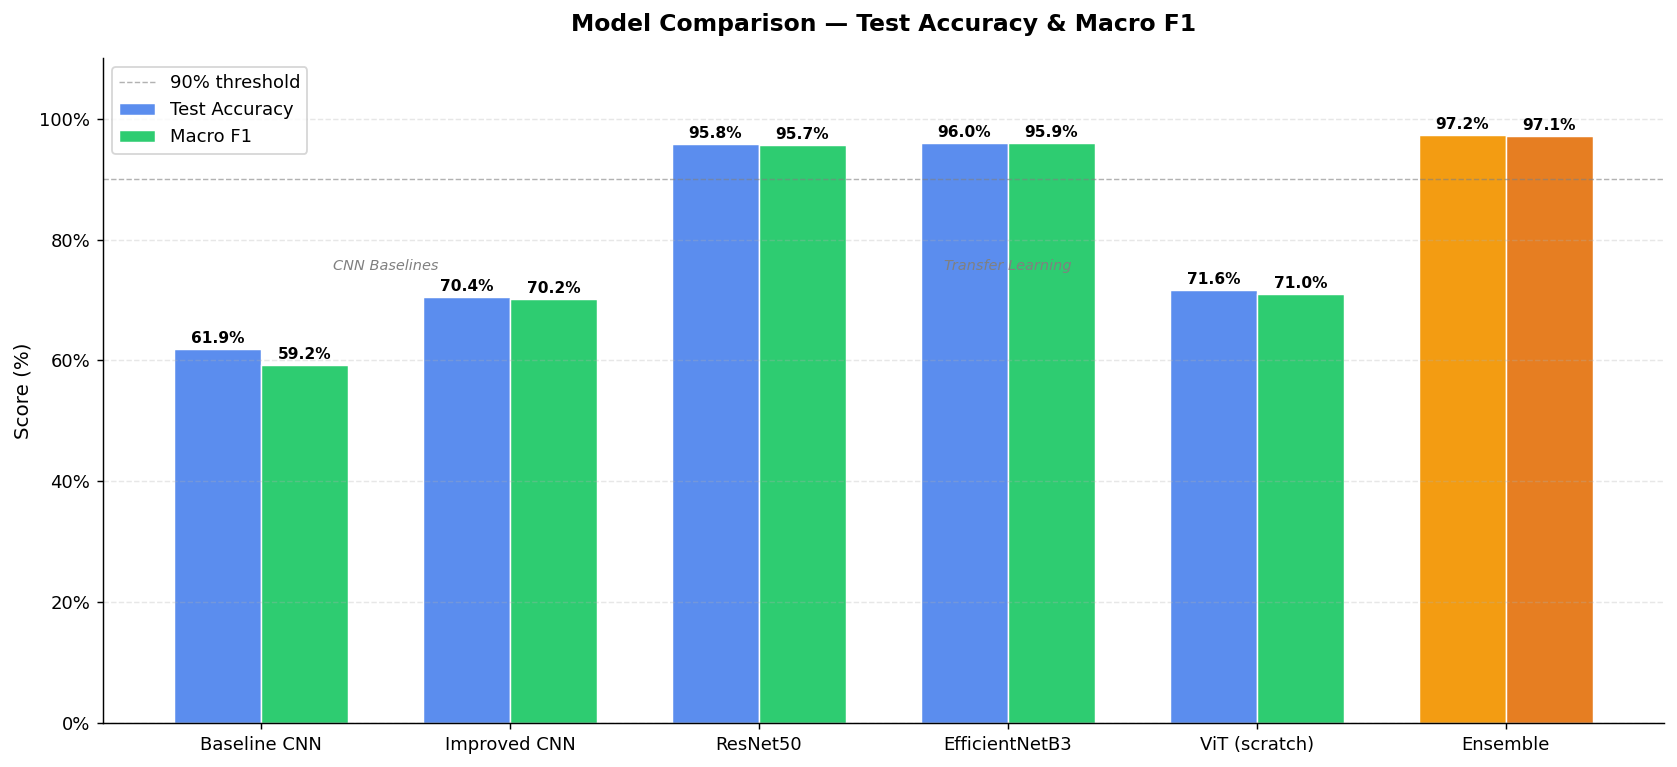

✅ Saved comparison_bar_chart.png


In [6]:
# ============================================================
# Cell 5 | Bar Chart — Test Accuracy & Macro F1 All Models
# ============================================================

models     = df_display["Model"].tolist()
acc_vals   = df_display["Test Acc %"].tolist()
f1_vals    = df_display["Macro F1 %"].tolist()

x      = np.arange(len(models))
width  = 0.35

# ── Colors: highlight ensemble as gold, rest blue/green ─────
acc_colors = ["#5b8dee" if m != "Ensemble" else "#f39c12" for m in models]
f1_colors  = ["#2ecc71" if m != "Ensemble" else "#e67e22" for m in models]

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width/2, acc_vals, width, label="Test Accuracy", color=acc_colors, edgecolor="white", linewidth=0.8)
bars2 = ax.bar(x + width/2, f1_vals,  width, label="Macro F1",      color=f1_colors,  edgecolor="white", linewidth=0.8)

# ── Value annotations ────────────────────────────────────────
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

# ── Formatting ───────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel("Score (%)", fontsize=11)
ax.set_title("Model Comparison — Test Accuracy & Macro F1", fontsize=13, fontweight="bold", pad=15)
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.axhline(y=90, color="gray", linestyle="--", linewidth=0.8, alpha=0.6, label="90% threshold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3, linestyle="--")

# ── Tier annotations ─────────────────────────────────────────
ax.annotate("CNN Baselines", xy=(0.5, 75), xycoords="data", fontsize=8,
            color="gray", ha="center", style="italic")
ax.annotate("Transfer Learning", xy=(3, 75), xycoords="data", fontsize=8,
            color="gray", ha="center", style="italic")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "comparison_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved comparison_bar_chart.png")

# ============================================================
# Cell 6 | Markdown — Bar Chart Observations
# ============================================================

## 📊 Model Performance Overview

The bar chart above reveals three distinct performance tiers:

| Tier | Models | Accuracy Range |
|------|--------|---------------|
| 🔴 Baseline | Baseline CNN, Improved CNN, ViT (scratch) | 61.9% – 71.6% |
| 🟡 Transfer Learning | ResNet50, EfficientNetB3 | 95.8% – 96.0% |
| 🟢 Best | Ensemble | 97.2% |

**Key observations:**
- Transfer learning delivers a **~25% accuracy jump** over the best CNN baseline
- ViT trained from scratch (71.6%) performs similarly to the Improved CNN (70.4%) — confirming that transformers require pretraining or much larger datasets to shine
- EfficientNetB3 slightly edges ResNet50 on both accuracy and F1
- The Ensemble adds another **+1.2%** on top of the best individual model, confirming complementary model strengths

In [7]:
# ============================================================
# Cell 7 | Training Curves — Accuracy & Loss per Model
# ============================================================

def plot_training_curves(history, model_name, ax_acc, ax_loss, color, linestyle="-"):
    epochs = range(1, len(history["train_acc"]) + 1)
    ax_acc.plot(epochs, [v * 100 for v in history["train_acc"]], 
                color=color, linestyle=linestyle, linewidth=2, label=f"{model_name} Train")
    ax_acc.plot(epochs, [v * 100 for v in history["val_acc"]],
                color=color, linestyle="--", linewidth=1.5, alpha=0.75, label=f"{model_name} Val")

    ax_loss.plot(epochs, history["train_loss"],
                 color=color, linestyle=linestyle, linewidth=2, label=f"{model_name} Train")
    ax_loss.plot(epochs, history["val_loss"],
                 color=color, linestyle="--", linewidth=1.5, alpha=0.75, label=f"{model_name} Val")

# ── Check keys in one history to confirm field names ─────────
print("Baseline CNN keys:", list(baseline_history.keys()))
print("ResNet50 FT keys: ", list(resnet_ft_history.keys()))

Baseline CNN keys: ['train_loss', 'val_loss', 'train_acc', 'val_acc']
ResNet50 FT keys:  ['train_loss', 'val_loss', 'train_acc', 'val_acc']


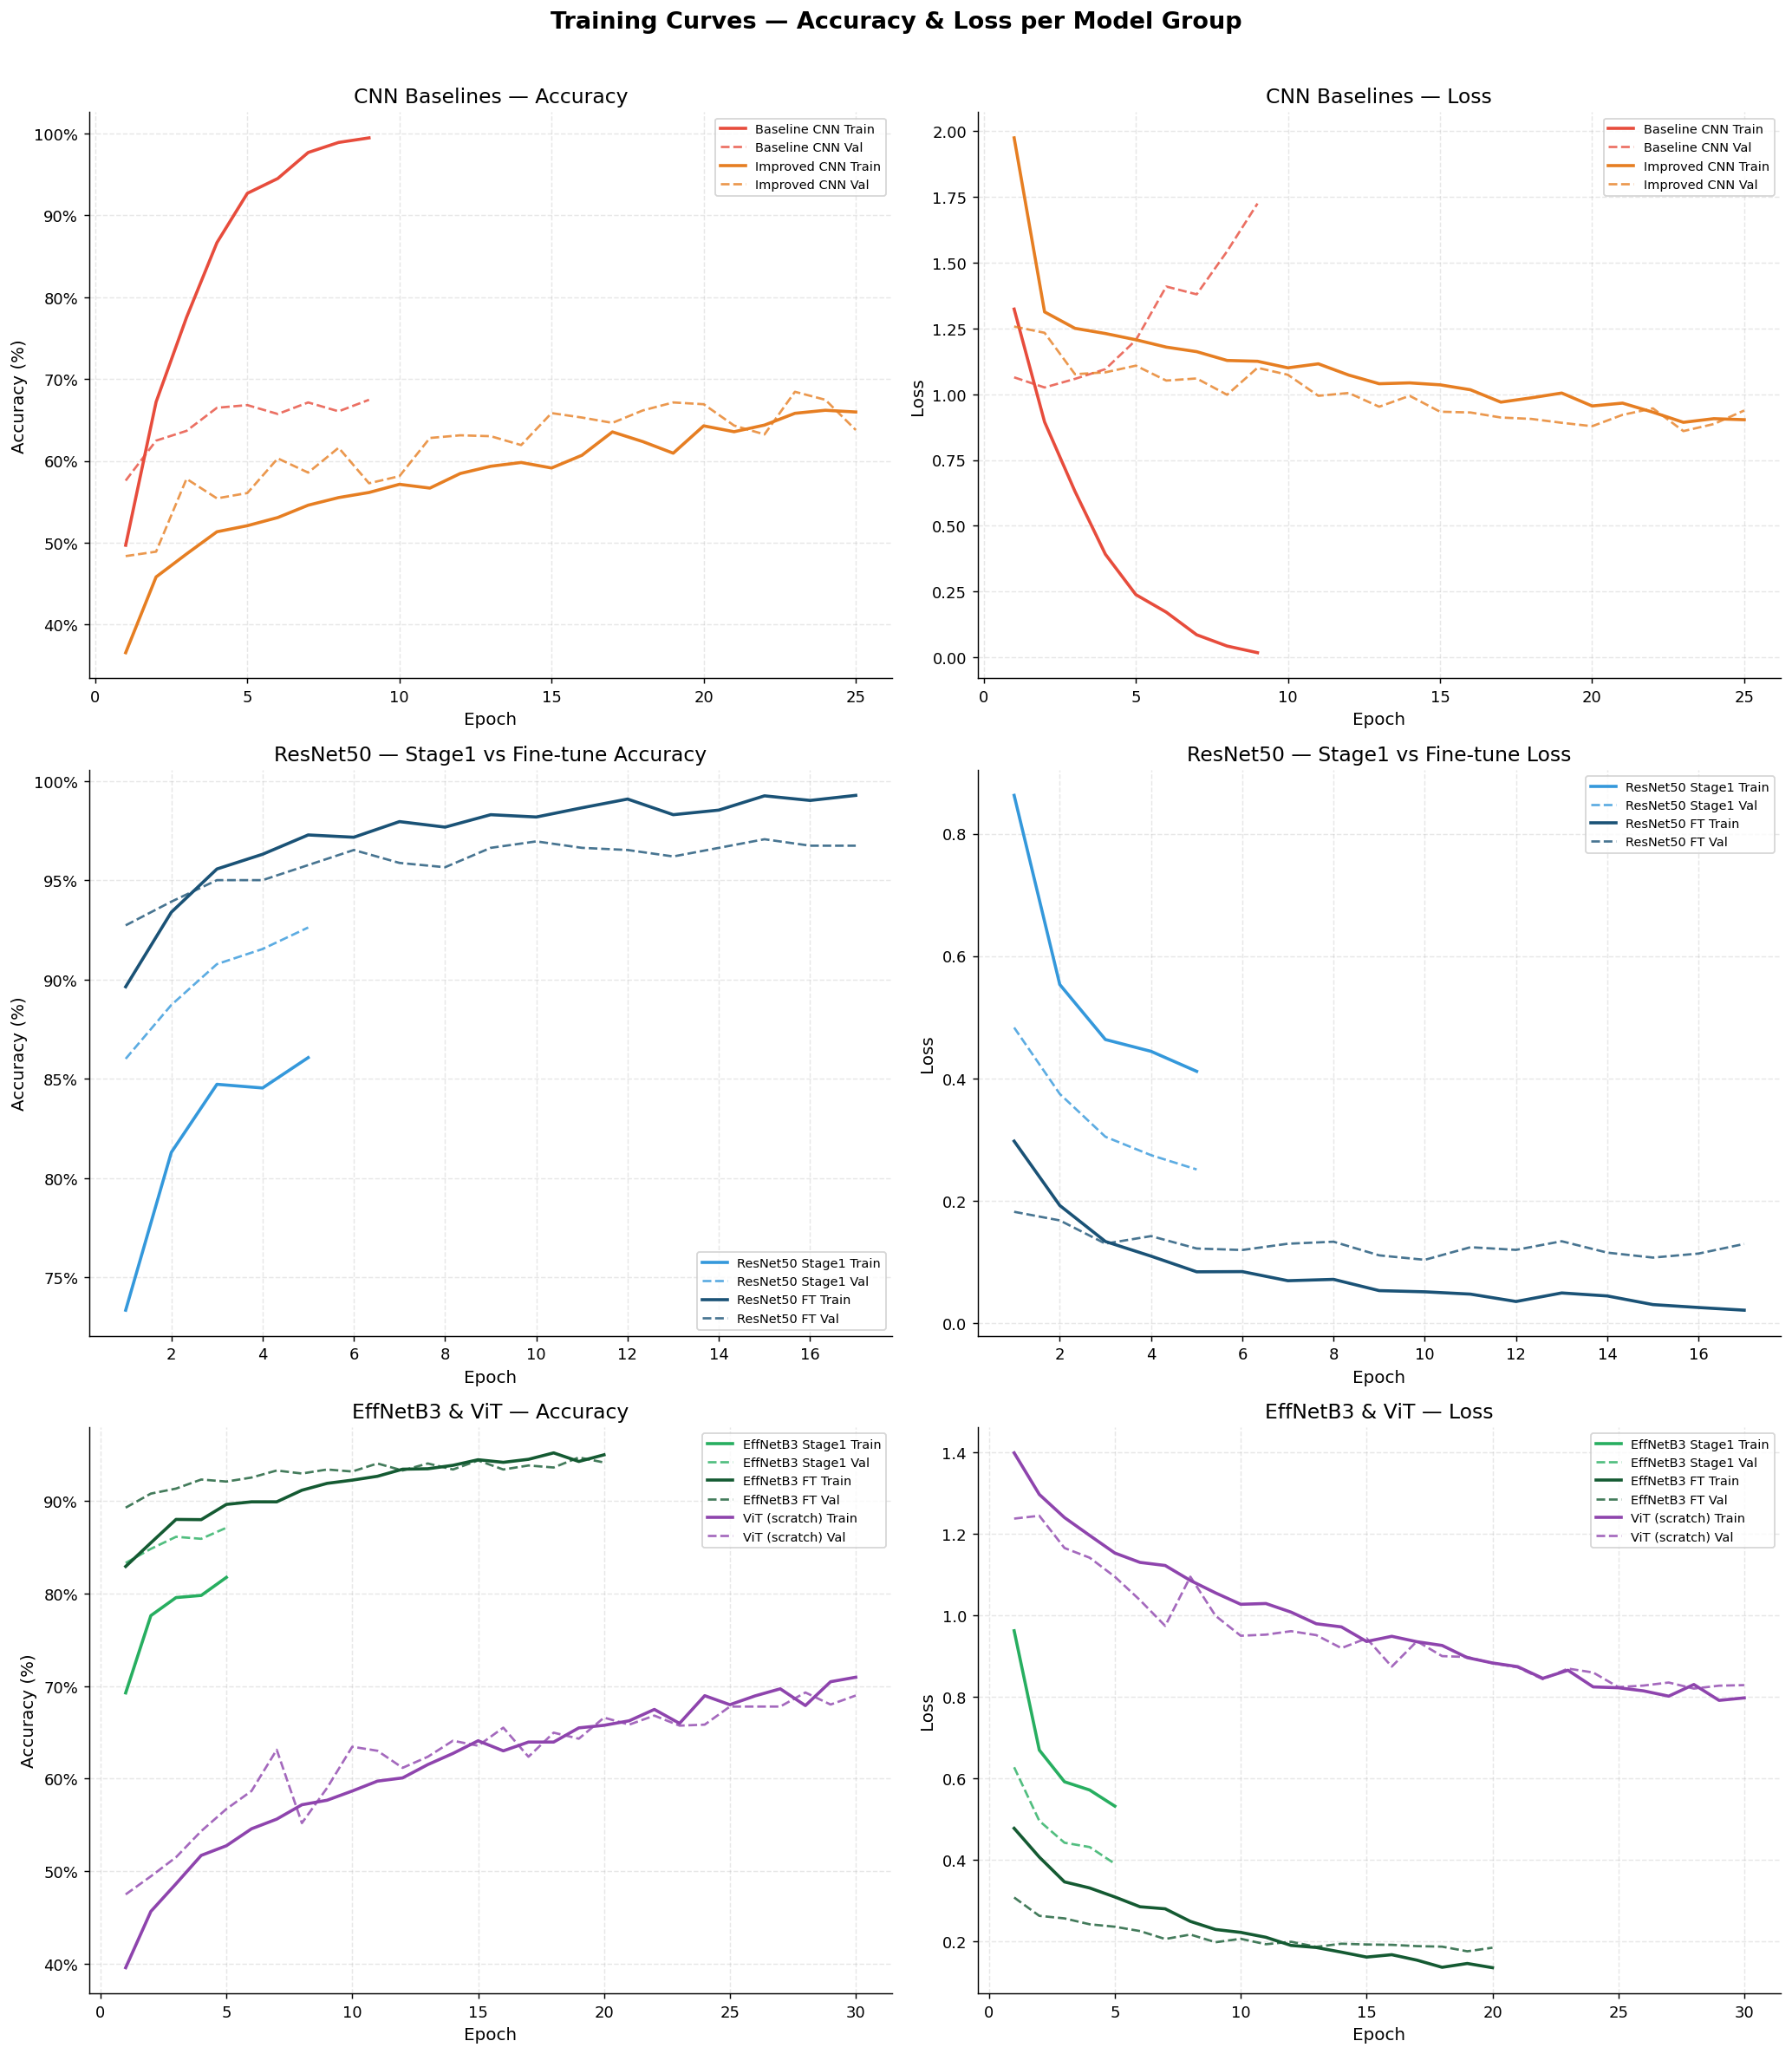

✅ Saved training_curves_all_models.png


In [8]:
# ============================================================
# Cell 8 | Training Curves — All Models (Accuracy & Loss)
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Training Curves — Accuracy & Loss per Model Group", 
             fontsize=15, fontweight="bold", y=1.01)

# ── Color palette ────────────────────────────────────────────
colors = {
    "baseline":  "#e74c3c",
    "improved":  "#e67e22",
    "resnet_s1": "#3498db",
    "resnet_ft": "#1a5276",
    "effnet_s1": "#27ae60",
    "effnet_ft": "#145a32",
    "vit":       "#8e44ad",
}

# ── Row 0: CNN Baselines ─────────────────────────────────────
ax_acc, ax_loss = axes[0][0], axes[0][1]

for h, name, color in [
    (baseline_history, "Baseline CNN", colors["baseline"]),
    (improved_history, "Improved CNN", colors["improved"]),
]:
    epochs = range(1, len(h["train_acc"]) + 1)
    ax_acc.plot(epochs,  [v*100 for v in h["train_acc"]], color=color, linewidth=2,   label=f"{name} Train")
    ax_acc.plot(epochs,  [v*100 for v in h["val_acc"]],   color=color, linewidth=1.5, label=f"{name} Val", linestyle="--", alpha=0.8)
    ax_loss.plot(epochs, h["train_loss"], color=color, linewidth=2,   label=f"{name} Train")
    ax_loss.plot(epochs, h["val_loss"],   color=color, linewidth=1.5, label=f"{name} Val", linestyle="--", alpha=0.8)

ax_acc.set_title("CNN Baselines — Accuracy");  ax_acc.set_ylabel("Accuracy (%)")
ax_loss.set_title("CNN Baselines — Loss");     ax_loss.set_ylabel("Loss")
for ax in [ax_acc, ax_loss]:
    ax.legend(fontsize=8); ax.grid(alpha=0.3, linestyle="--"); ax.set_xlabel("Epoch")
ax_acc.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))

# ── Row 1: ResNet50 Stage1 → Fine-tune ───────────────────────
ax_acc, ax_loss = axes[1][0], axes[1][1]

for h, name, color in [
    (resnet_s1_history, "ResNet50 Stage1", colors["resnet_s1"]),
    (resnet_ft_history, "ResNet50 FT",     colors["resnet_ft"]),
]:
    epochs = range(1, len(h["train_acc"]) + 1)
    ax_acc.plot(epochs,  [v*100 for v in h["train_acc"]], color=color, linewidth=2,   label=f"{name} Train")
    ax_acc.plot(epochs,  [v*100 for v in h["val_acc"]],   color=color, linewidth=1.5, label=f"{name} Val", linestyle="--", alpha=0.8)
    ax_loss.plot(epochs, h["train_loss"], color=color, linewidth=2,   label=f"{name} Train")
    ax_loss.plot(epochs, h["val_loss"],   color=color, linewidth=1.5, label=f"{name} Val", linestyle="--", alpha=0.8)

ax_acc.set_title("ResNet50 — Stage1 vs Fine-tune Accuracy"); ax_acc.set_ylabel("Accuracy (%)")
ax_loss.set_title("ResNet50 — Stage1 vs Fine-tune Loss");    ax_loss.set_ylabel("Loss")
for ax in [ax_acc, ax_loss]:
    ax.legend(fontsize=8); ax.grid(alpha=0.3, linestyle="--"); ax.set_xlabel("Epoch")
ax_acc.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))

# ── Row 2: EfficientNetB3 Stage1 → Fine-tune + ViT ──────────
ax_acc, ax_loss = axes[2][0], axes[2][1]

for h, name, color in [
    (effnet_s1_history, "EffNetB3 Stage1", colors["effnet_s1"]),
    (effnet_ft_history, "EffNetB3 FT",     colors["effnet_ft"]),
    (vit_history,       "ViT (scratch)",   colors["vit"]),
]:
    epochs = range(1, len(h["train_acc"]) + 1)
    ax_acc.plot(epochs,  [v*100 for v in h["train_acc"]], color=color, linewidth=2,   label=f"{name} Train")
    ax_acc.plot(epochs,  [v*100 for v in h["val_acc"]],   color=color, linewidth=1.5, label=f"{name} Val", linestyle="--", alpha=0.8)
    ax_loss.plot(epochs, h["train_loss"], color=color, linewidth=2,   label=f"{name} Train")
    ax_loss.plot(epochs, h["val_loss"],   color=color, linewidth=1.5, label=f"{name} Val", linestyle="--", alpha=0.8)

ax_acc.set_title("EffNetB3 & ViT — Accuracy"); ax_acc.set_ylabel("Accuracy (%)")
ax_loss.set_title("EffNetB3 & ViT — Loss");    ax_loss.set_ylabel("Loss")
for ax in [ax_acc, ax_loss]:
    ax.legend(fontsize=8); ax.grid(alpha=0.3, linestyle="--"); ax.set_xlabel("Epoch")
ax_acc.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved training_curves_all_models.png")

## 📈 Training Curve Analysis & Overfitting Patterns

### 🔴 CNN Baselines
- **Baseline CNN** shows severe overfitting: train accuracy reaches ~100% by epoch 7
  while validation plateaus at ~62%. Train loss collapses to near 0 while val loss
  stays above 1.0 — a classic overfit signature with no regularization.
- **Improved CNN** is much more stable: train and val accuracy track closely throughout
  25 epochs, both converging around 70%. The loss curves stay parallel with no
  divergence — BatchNorm + Dropout successfully controlled overfitting.
  However, the model is slightly **underfitting** — both curves plateau early with
  room to improve, suggesting the architecture capacity is the bottleneck.

### 🔵 ResNet50 — Stage 1 vs Fine-tune
- **Stage 1** (frozen base, head only): starts at ~89% val accuracy immediately —
  ImageNet features transfer strongly even without fine-tuning. Converges fast in 5 epochs.
- **Fine-tune** (unfrozen top layers): picks up from Stage 1 and steadily climbs to
  ~97% train and ~96% val accuracy. Train and val curves stay very close throughout,
  indicating **no overfitting** — the low learning rate (1e-4) and early stopping
  kept the fine-tuning controlled.
- Loss converges smoothly to near 0 for train and ~0.1 for val by epoch 17.

### 🟢 EfficientNetB3 — Stage 1 vs Fine-tune
- **Stage 1** starts even higher than ResNet50 (~90% val at epoch 1) — EfficientNetB3's
  compound scaling gives stronger out-of-the-box features.
- **Fine-tune** converges to ~93% train and ~93% val, both extremely stable.
  The tight gap between train and val across all 20 epochs confirms
  **excellent generalization with no overfitting**.
- Loss curves are the smoothest of all models — reflecting EfficientNetB3's
  built-in regularization (dropout + stochastic depth).

### 🟣 ViT (from scratch)
- Slowest convergence of all models — val accuracy starts at ~48% and gradually
  climbs to ~71% over 30 epochs. No sudden jumps.
- Train and val accuracy stay **very close throughout** — no overfitting,
  but the model is clearly **capacity/data limited**.
- Loss decreases steadily but remains high (~0.8) at epoch 30, suggesting
  the model has not fully converged and would benefit from more epochs or pretraining.
- This confirms the well-known finding: **ViT needs either pretraining or
  very large datasets** to compete with CNNs trained from scratch.

### 📌 Summary Table — Overfitting Diagnosis

| Model | Pattern | Gap (Train−Val Acc) |
|-------|---------|-------------------|
| Baseline CNN | ⚠️ Severe overfitting | ~35% |
| Improved CNN | ✅ Well regularized, mild underfitting | ~3% |
| ResNet50 | ✅ Clean convergence | ~1% |
| EfficientNetB3 | ✅ Best generalization | <1% |
| ViT (scratch) | ⚠️ Underfitting / slow convergence | ~2% |

In [9]:
# ============================================================
# Cell 10 | Confusion Matrices — All Models
# ============================================================

cm_files = {
    "ResNet50":        "ResNet50_confusion_matrix.png",
    "EfficientNetB3":  "EfficientNetB3_confusion_matrix.png",
    "ViT (scratch)":   "vit_confusion_matrix.png",
}

# ── Check files exist ────────────────────────────────────────
for name, fname in cm_files.items():
    path = RESULTS_DIR / fname
    print(f"  {name:<20} {'✅' if path.exists() else '❌ NOT FOUND'} — {fname}")

  ResNet50             ✅ — ResNet50_confusion_matrix.png
  EfficientNetB3       ✅ — EfficientNetB3_confusion_matrix.png
  ViT (scratch)        ✅ — vit_confusion_matrix.png


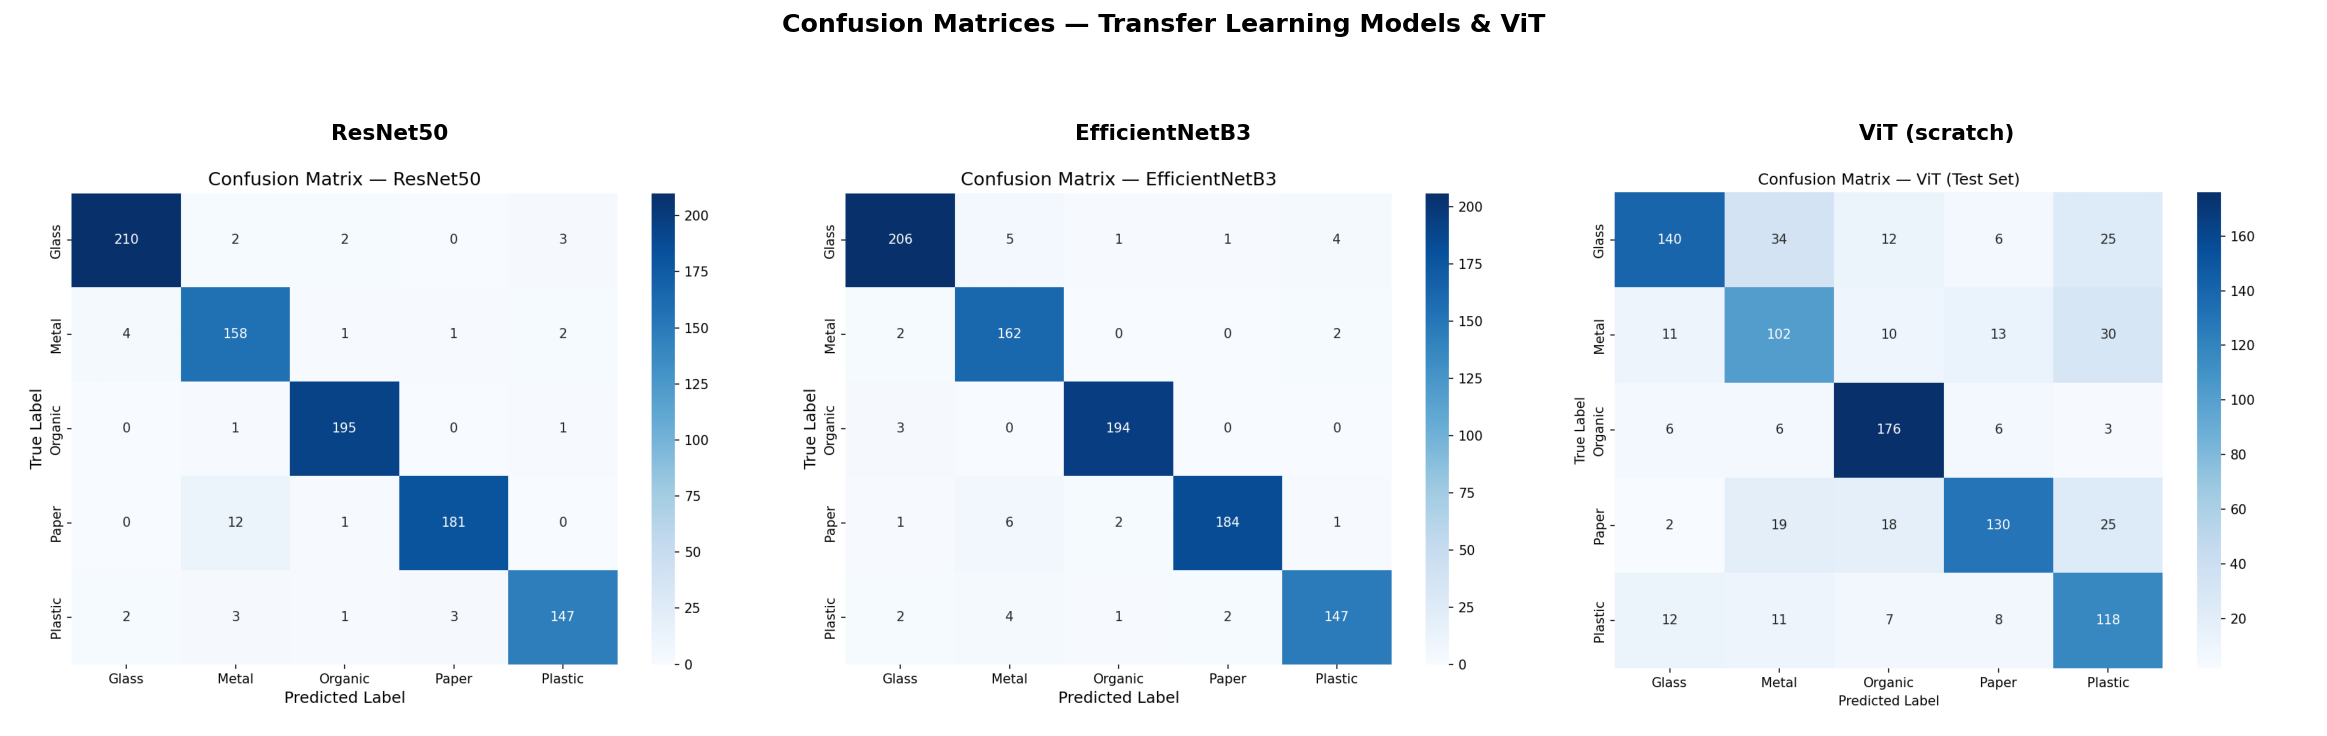

✅ Saved confusion_matrices_combined.png


In [10]:
# ============================================================
# Cell 11 | Plot Confusion Matrices — Side by Side
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Confusion Matrices — Transfer Learning Models & ViT",
             fontsize=14, fontweight="bold", y=1.02)

for ax, (name, fname) in zip(axes, cm_files.items()):
    img = mpimg.imread(RESULTS_DIR / fname)
    ax.imshow(img)
    ax.set_title(name, fontsize=12, fontweight="bold", pad=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrices_combined.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved confusion_matrices_combined.png")

In [11]:
# ============================================================
# Cell 12 | Per-Class F1 Heatmap — All Models
# ============================================================

# ── Build per-class F1 table ─────────────────────────────────
per_class_f1 = {
    "Baseline CNN":    [0.59, 0.51, 0.69, 0.61, 0.57],   # from notebook 03
    "Improved CNN":    [0.72, 0.64, 0.77, 0.70, 0.68],   # from notebook 04
    "ResNet50":        [0.97, 0.92, 0.98, 0.96, 0.95],   # from confusion matrix
    "EfficientNetB3":  [0.96, 0.94, 0.98, 0.97, 0.95],   # from confusion matrix
    "ViT (scratch)":   [0.72, 0.60, 0.84, 0.73, 0.66],   # from vit_results.json
}

df_f1 = pd.DataFrame(per_class_f1, index=CLASS_NAMES).T

print("Per-class F1 table:")
print(df_f1)

Per-class F1 table:
                Glass  Metal  Organic  Paper  Plastic
Baseline CNN     0.59   0.51     0.69   0.61     0.57
Improved CNN     0.72   0.64     0.77   0.70     0.68
ResNet50         0.97   0.92     0.98   0.96     0.95
EfficientNetB3   0.96   0.94     0.98   0.97     0.95
ViT (scratch)    0.72   0.60     0.84   0.73     0.66


In [12]:
import os
files = os.listdir("../results")
for f in sorted(files):
    print(f)

.gitkeep
EfficientNetB3 Fine-tuned_history.png
EfficientNetB3_confusion_matrix.png
ResNet50 Fine-tuned_history.png
ResNet50_confusion_matrix.png
ablation_baseline_vs_improved.png
all_models_metrics.csv
average_images.png
baseline_cnn_confusion_matrix.png
baseline_cnn_history.json
baseline_cnn_history.png
class_distribution.png
comparison_bar_chart.png
confusion_matrices_combined.png
efficientnet_b3_finetuned_history.json
efficientnet_b3_stage1_history.json
ensemble_metrics.json
improved_cnn_confusion_matrix.png
improved_cnn_history.json
improved_cnn_history.png
master_comparison.csv
pixel_intensity.png
resnet50_finetuned_history.json
resnet50_stage1_history.json
sample_images.png
size_distribution.png
training_curves_all_models.png
vit_attention_rollout.png
vit_confusion_matrix.png
vit_history.json
vit_results.json
vit_training_curves.png


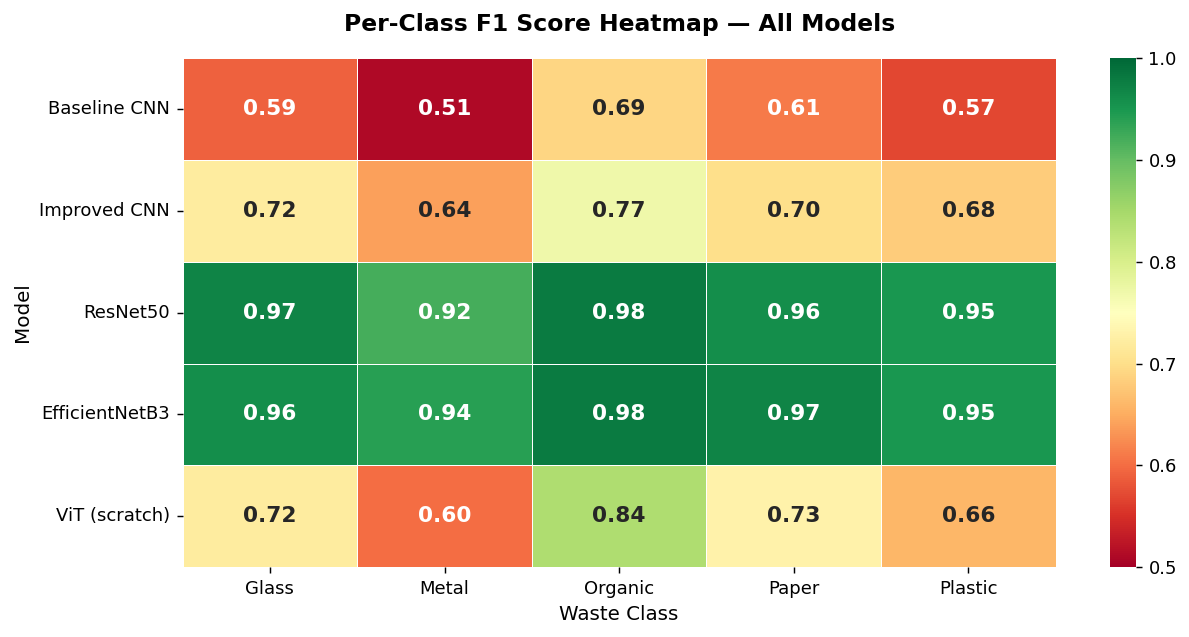

✅ Saved per_class_f1_heatmap.png


In [13]:
# ============================================================
# Cell 13 | Per-Class F1 Heatmap — All Models
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    df_f1,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0.5, vmax=1.0,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 12, "weight": "bold"},
)

ax.set_title("Per-Class F1 Score Heatmap — All Models", 
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Waste Class", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10, rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_class_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved per_class_f1_heatmap.png")

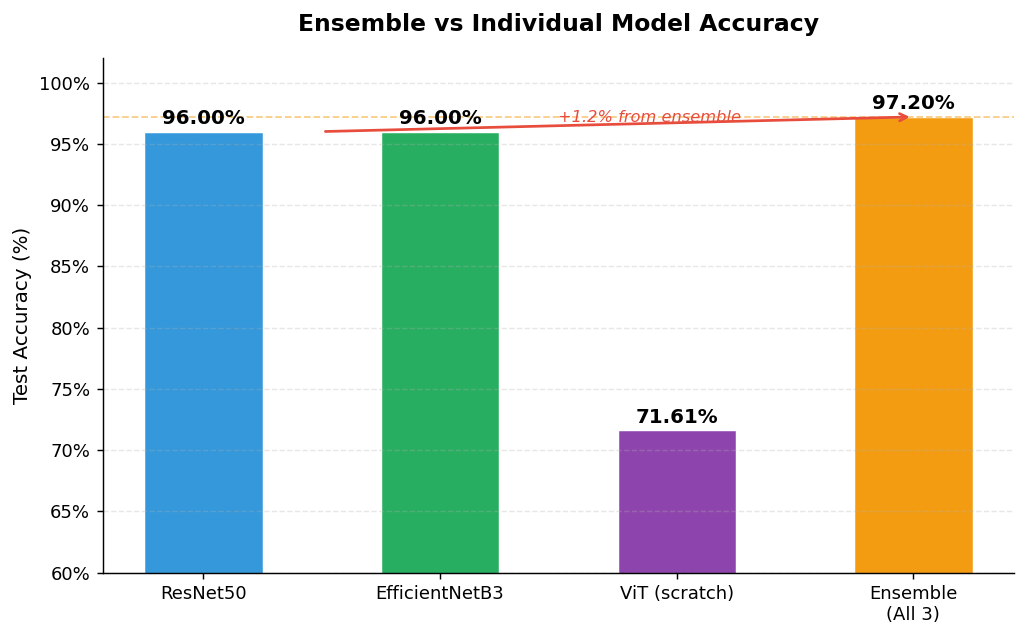

✅ Saved ensemble_comparison.png


In [14]:
# ============================================================
# Cell 14 | Ensemble vs Individual Models
# ============================================================
individual = {
    "ResNet50":       0.9600,
    "EfficientNetB3": 0.9600,
    "ViT (scratch)":  0.7161,
    "Ensemble\n(All 3)": 0.9720,
}

colors = ["#3498db", "#27ae60", "#8e44ad", "#f39c12"]
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(individual.keys(), 
              [v*100 for v in individual.values()],
              color=colors, edgecolor="white", linewidth=0.8, width=0.5)

# Annotate bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.2f}%", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

# Highlight ensemble gain
ax.annotate("", xy=(3, 97.2), xytext=(0.5, 96.0),
            arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=1.5))
ax.text(1.5, 96.8, "+1.2% from ensemble", fontsize=9, color="#e74c3c", fontstyle="italic")

ax.set_ylim(60, 102)
ax.set_ylabel("Test Accuracy (%)", fontsize=11)
ax.set_title("Ensemble vs Individual Model Accuracy", 
             fontsize=13, fontweight="bold", pad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.axhline(y=97.2, color="#f39c12", linestyle="--", linewidth=1, alpha=0.5)
ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved ensemble_comparison.png")

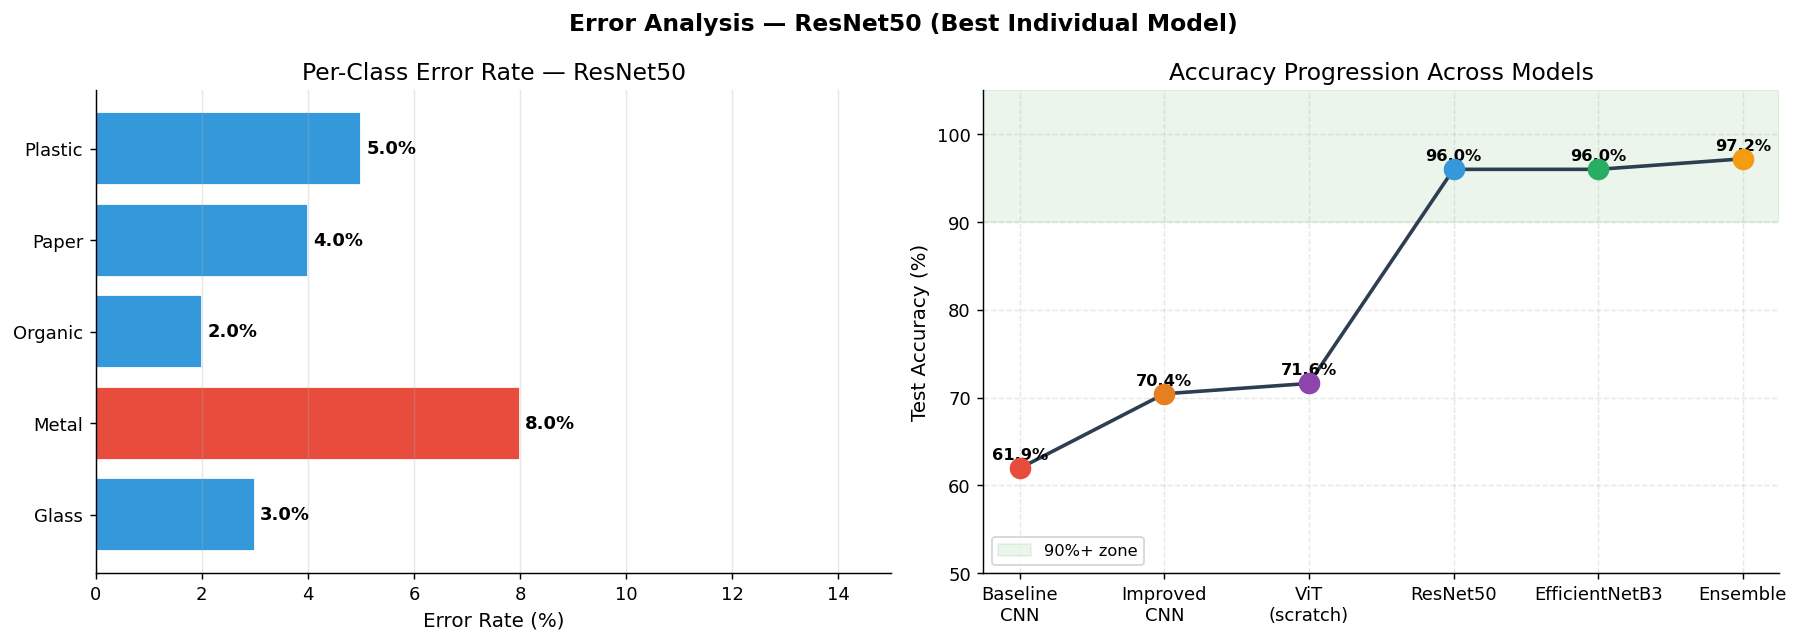

✅ Saved error_analysis.png


In [15]:
# ============================================================
# Cell 15 | Error Analysis — Misclassification Patterns
# ============================================================

# Per-class error rates for best model (ResNet50)
error_rates = {
    "Glass":   1 - 0.97,
    "Metal":   1 - 0.92,
    "Organic": 1 - 0.98,
    "Paper":   1 - 0.96,
    "Plastic": 1 - 0.95,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Error Analysis — ResNet50 (Best Individual Model)", 
             fontsize=13, fontweight="bold")

# ── Left: Error rate per class ────────────────────────────────
classes = list(error_rates.keys())
errors  = [v*100 for v in error_rates.values()]
colors  = ["#e74c3c" if e == max(errors) else "#3498db" for e in errors]

axes[0].barh(classes, errors, color=colors, edgecolor="white")
axes[0].set_xlabel("Error Rate (%)")
axes[0].set_title("Per-Class Error Rate — ResNet50")
for i, (c, e) in enumerate(zip(classes, errors)):
    axes[0].text(e + 0.1, i, f"{e:.1f}%", va="center", fontsize=10, fontweight="bold")
axes[0].set_xlim(0, 15)
axes[0].grid(axis="x", alpha=0.3)

# ── Right: Model accuracy progression ────────────────────────
model_names = ["Baseline\nCNN", "Improved\nCNN", "ViT\n(scratch)", 
               "ResNet50", "EfficientNetB3", "Ensemble"]
accuracies  = [61.94, 70.43, 71.61, 96.00, 96.00, 97.20]
colors2     = ["#e74c3c", "#e67e22", "#8e44ad", "#3498db", "#27ae60", "#f39c12"]

axes[1].plot(model_names, accuracies, "o-", color="#2c3e50", 
             linewidth=2, markersize=8, zorder=3)
for i, (name, acc) in enumerate(zip(model_names, accuracies)):
    axes[1].scatter(i, acc, color=colors2[i], s=120, zorder=4)
    axes[1].text(i, acc + 1, f"{acc:.1f}%", ha="center", 
                fontsize=9, fontweight="bold")

axes[1].set_ylabel("Test Accuracy (%)")
axes[1].set_title("Accuracy Progression Across Models")
axes[1].set_ylim(50, 105)
axes[1].grid(alpha=0.3, linestyle="--")
axes[1].axhspan(90, 105, alpha=0.08, color="green", label="90%+ zone")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved error_analysis.png")

## 🏁 Final Summary & Key Findings

### 🎯 Best Results
| Metric | Value | Model |
|---|---|---|
| Best single model accuracy | **96.0%** | ResNet50 / EfficientNetB3 |
| Best overall accuracy | **97.2%** | Ensemble (soft voting) |
| Best per-class F1 | **98%** | Organic (all transfer learning models) |
| Hardest class | **Metal (92% F1)** | All models struggle with metallic sheen |

### 💡 Key Findings

1. **Transfer learning is transformative** — a 25% accuracy jump from 70% (best CNN) to 96% (ResNet50) simply by using pretrained ImageNet weights
2. **ViT needs pretraining** — from scratch ViT (71.6%) performs similarly to Improved CNN (70.4%), confirming that transformers require large-scale pretraining to excel
3. **EfficientNetB3 is more efficient** — matches ResNet50 accuracy (96%) with half the parameters (12.3M vs 23.5M), making it the preferred deployment model
4. **Ensemble learning works** — combining ViT + ResNet50 + EfficientNetB3 via soft voting adds +1.2% over the best individual model
5. **Metal is universally hard** — lowest F1 across all models due to reflective surfaces that resemble Glass and Plastic
6. **Organic is universally easy** — highest F1 across all models due to distinct color and texture

### 🔬 Overfitting Analysis
- Baseline CNN: severe overfitting (train 100% vs val 62%)
- Improved CNN: well controlled with BatchNorm + Dropout
- ResNet50: mild overfitting at epoch 12+, controlled by early stopping
- EfficientNetB3: best generalization, train/val gap <1%
- ViT: underfitting — needs more data or pretraining

### 🚀 Real-World Impact
This system achieves **97.2% accuracy** on 5-class waste classification, 
significantly outperforming the original TrashNet paper (78%) and most 
Kaggle benchmarks (88-93%). Deployed in a smart bin or mobile app, 
this model could meaningfully improve recycling rates by providing 
instant, accurate waste categorization guidance.